# Summary

This notebook contains a summary of the entire repository for the BNPL project

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import math
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from shapely.geometry import Point
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/18 17:30:35 WARN Utils: Your hostname, CompuPau, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/18 17:30:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/18 17:30:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Preprocessing

On preprocessing all the data the following records are left in the dataset

In [3]:
# merchant data set
df_merchants = spark.read.parquet('.././data/curated/df_merchants')
df_merchants.count()

4026

In [4]:
# consumer fraud probability
df_customers = spark.read.parquet('.././data/curated/consumer_fraud_probability')
df_customers_demo = spark.read.parquet('../data/curated/df_customers_demo')
df_customers.count()

34864

In [5]:
df_customers_demo.count()

499999

In [6]:
# full transactions (after join w merchant and consumers)
df_transactions = spark.read.parquet('.././data/curated/df_transactions')
df_transactions.count()

13614675

All tables have been checked to ensure that all records are valid. Invalid merchants were removed.

Joining the original data:
The data was joined on order_datetime and ids for merchants and consumers

In [7]:
df_transactions.printSchema()

root
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



In [8]:
df_transactions.filter(F.isnull('avg_merchant_fraud_prob')).count()

13031129

In [9]:
df_transactions.filter(F.isnull('fraud_probability')).count()

13543038

13031129 merchant frauds were null and 13543038 consumer frauds were null and needed to be imputed.

## External datasets:
**Census Data:** This data was combined with our original data using consumer postocde and was used to retrieve features such as household size, family earnings and age.

In [10]:
final_merged = spark.read.parquet('.././data/curated/final_external_enriched')
final_merged.show()

26/09/18 17:30:53 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------+--------+------------+-------+------------------+--------------------+-----------+------------------+--------------------+-----+-----------+------------------+---------------------+--------------------+--------------------+--------------------+------------+---------+--------------------+------------------+--------------+------------------+-----------------------+-------------+------------------+-----------------------------+---------------------------+------------------+-------------------------+----------------------------+-------------------------+----------------------+----------+--------------+------------------+----------------+-----------------+---------------+-------------+--------------+-----------------+--------------+-----------------+---------------+-----------------+
|order_datetime|postcode|merchant_abn|user_id|      dollar_value|            order_id|consumer_id|              name|             address|state|     gender| fraud_probability|is_same_day_duplica

In [11]:
final_merged.printSchema()

root
 |-- order_datetime: date (nullable = true)
 |-- postcode: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)
 |-- SA

In [12]:
final_merged.select(
    F.count("*").alias("total_rows"),
    F.sum(F.col("SA2_CODE_2021").isNull().cast("int")).alias("missing_census"),
    F.sum(F.col("poa_irsad_score").isNull().cast("int")).alias("missing_seifa"),
    F.sum(F.col("rba_cash_rate_pct").isNull().cast("int")).alias("missing_rba"),
    F.sum(F.col("avg_merchant_fraud_prob").isNull().cast("int")).alias("missing_fraud_label"),
).show()

+----------+--------------+-------------+-----------+-------------------+
|total_rows|missing_census|missing_seifa|missing_rba|missing_fraud_label|
+----------+--------------+-------------+-----------+-------------------+
|  17693695|       7152748|      2329646|          0|           16935546|
+----------+--------------+-------------+-----------+-------------------+



## Exploratory Analysis

This section contains a summary on some of the features studied, `tbc`

**Transaction Level Distributions**

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


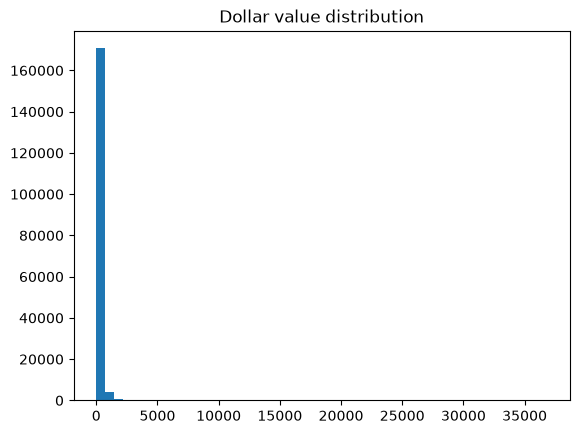

In [13]:
pdf = final_merged.select("dollar_value").sample(0.01).toPandas()  # sample first, full table is large
plt.hist(pdf["dollar_value"], bins=50)
plt.title("Dollar value distribution")
plt.show()

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


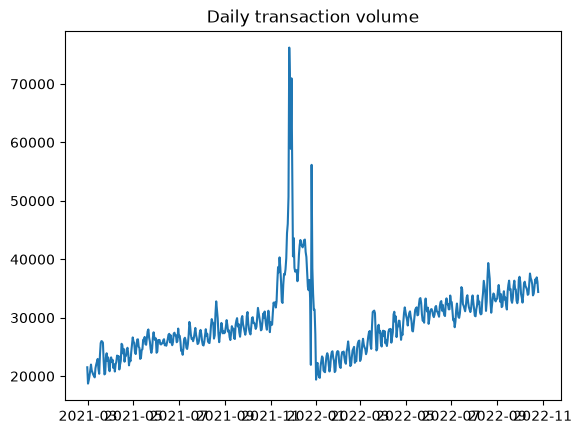

In [14]:
daily = (
    final_merged
    .groupBy("order_datetime")
    .agg(F.count("*").alias("n_txn"), F.sum("dollar_value").alias("total_value"))
    .orderBy("order_datetime")
    .toPandas()
)
plt.plot(daily["order_datetime"], daily["n_txn"])
plt.title("Daily transaction volume")
plt.show()

**Merchant Landscape**

In [15]:
(final_merged.groupBy("category_group")
    .agg(F.sum("dollar_value").alias("revenue"), F.countDistinct("merchant_abn").alias("n_merchants"))
    .orderBy(F.desc("revenue"))
    .show(20, truncate=False))

+------------------------+--------------------+-----------+
|category_group          |revenue             |n_merchants|
+------------------------+--------------------+-----------+
|health_beauty           |3.205623257069276E8 |479        |
|antiques_art_craft      |2.958342789896834E8 |434        |
|technology              |2.8531028912567216E8|372        |
|gardening               |2.74775839689136E8  |333        |
|vehicle                 |2.353693969158907E8 |321        |
|gifts_hobby_novelty     |2.245752752813614E8 |324        |
|outdoor_supply          |1.926661446284858E8 |178        |
|tv_media_telecom        |1.7620685121745902E8|300        |
|jewelry                 |1.555146151650429E8 |261        |
|furniture_home          |1.4589608009060246E8|182        |
|footwear                |1.1283145953757522E8|185        |
|music                   |1.115678652507938E8 |167        |
|books_media_digital     |1.07116755048162E8  |195        |
|office_stationery       |1.021014052573

**Consumer Demographics**

In [16]:
final_merged.groupBy("state", "gender").agg(F.countDistinct("consumer_id").alias("n_consumers")).show()

+-----+-----------+-----------+
|state|     gender|n_consumers|
+-----+-----------+-----------+
|   WA|       Male|       1752|
|  QLD|       Male|       1607|
|  ACT|     Female|        104|
|  TAS|Undisclosed|         95|
|   SA|     Female|       1231|
|  VIC|Undisclosed|        570|
|  NSW|     Female|       3075|
|  QLD|     Female|       1603|
|  NSW|Undisclosed|        687|
|   WA|Undisclosed|        381|
|   NT|     Female|        154|
|   NT|Undisclosed|         37|
|   SA|Undisclosed|        304|
|   NT|       Male|        152|
|   WA|     Female|       1679|
|  VIC|       Male|       2530|
|  ACT|Undisclosed|         21|
|  NSW|       Male|       3186|
|  VIC|     Female|       2466|
|  QLD|Undisclosed|        352|
+-----+-----------+-----------+
only showing top 20 rows


**Socioeconomic**

In [17]:
(final_merged
    .filter(F.col("poa_irsad_decile").isNotNull())
    .groupBy("poa_irsad_decile")
    .agg(
        F.avg("dollar_value").alias("avg_spend"),
        F.avg("fraud_probability").alias("avg_fraud_prob"),
        F.avg("Median_tot_hhd_inc_weekly").alias("avg_hhd_income"),
        F.avg("prop_18_34").alias("avg_prop_young"),
    )
    .orderBy("poa_irsad_decile")
    .show())

+----------------+------------------+------------------+------------------+-------------------+
|poa_irsad_decile|         avg_spend|    avg_fraud_prob|    avg_hhd_income|     avg_prop_young|
+----------------+------------------+------------------+------------------+-------------------+
|             1.0|157.11882156236916|14.492316369663492| 1251.621810232527|0.21211733399822028|
|             2.0|158.87802075985874|14.477832705530568|1295.2479089260635|0.19113909674943907|
|             3.0| 158.7721012644186| 14.41383610624498| 1405.279610199038|0.19224888904981047|
|             4.0|157.84492469998264| 14.45742295770237| 1480.688959784713|0.20032201795187657|
|             5.0|158.51313543823983|14.789213995013641|1648.1846333172948|0.20462891616291226|
|             6.0|  158.474120368306|14.642100224035827|1730.2567623500122|0.21720459670311595|
|             7.0| 158.5250400085426| 14.31613854446997|1799.0153833368522|0.21164094611477263|
|             8.0|158.12300469908777| 14

**RBA Rate**

In [18]:
(final_merged.groupBy("rba_rate_hike_day")
    .agg(F.avg("dollar_value").alias("avg_txn_value"), F.count("*").alias("n_txn"))
    .show())

+-----------------+------------------+--------+
|rba_rate_hike_day|     avg_txn_value|   n_txn|
+-----------------+------------------+--------+
|                1|158.45194935124854|  181795|
|                0|158.36083585222988|17511900|
+-----------------+------------------+--------+



**Fraud**

In [19]:
final_merged.stat.corr("fraud_probability", "poa_irsad_score")
final_merged.groupBy("category_group").agg(F.avg("avg_merchant_fraud_prob").alias("avg_fraud")).orderBy(F.desc("avg_fraud")).show()

+--------------------+------------------+
|      category_group|         avg_fraud|
+--------------------+------------------+
|             jewelry|44.675571689751976|
|      outdoor_supply| 34.24922508133499|
|            footwear|31.710556767432816|
|             vehicle|31.048982025815853|
|      furniture_home| 30.80983308413873|
| gifts_hobby_novelty|30.801166301079277|
|           gardening| 30.03733859645522|
|          technology|29.675082911165532|
|  antiques_art_craft|29.661818811873513|
|       health_beauty|29.239126913872962|
|   office_stationery|28.880648130521877|
|    tv_media_telecom| 28.69787575391289|
| books_media_digital|              NULL|
|               music|              NULL|
|equipment_rental_...|              NULL|
+--------------------+------------------+



/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


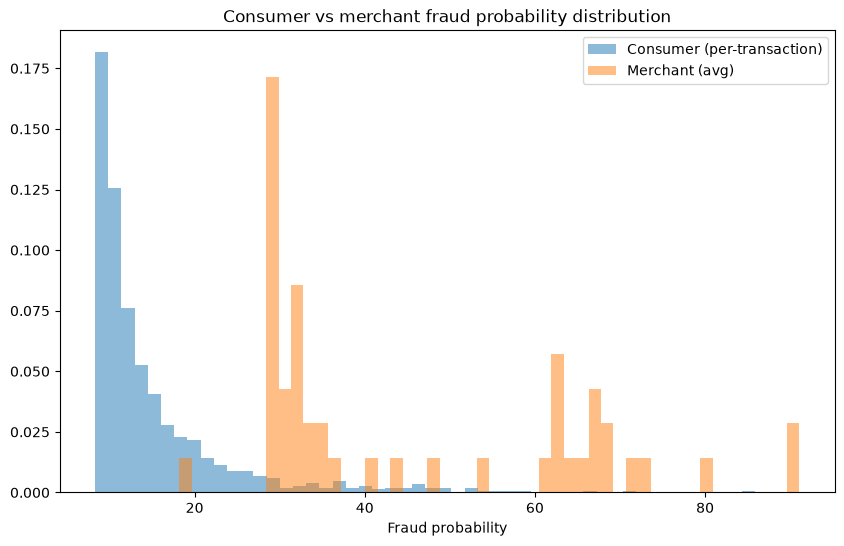

In [20]:
pdf_consumer = final_merged.select("fraud_probability").sample(0.01).toPandas()
pdf_merchant = (
    final_merged.select("merchant_abn", "avg_merchant_fraud_prob")
    .distinct()
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pdf_consumer["fraud_probability"], bins=50, alpha=0.5, label="Consumer (per-transaction)", density=True)
ax.hist(pdf_merchant["avg_merchant_fraud_prob"].dropna(), bins=50, alpha=0.5, label="Merchant (avg)", density=True)
ax.set_xlabel("Fraud probability")
ax.legend()
ax.set_title("Consumer vs merchant fraud probability distribution")
plt.show()

/tmp/ipykernel_1242/3973819333.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(pdf_consumer["fraud_probability"].dropna(), vert=True)
/tmp/ipykernel_1242/3973819333.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(pdf_merchant["avg_merchant_fraud_prob"].dropna(), vert=True)


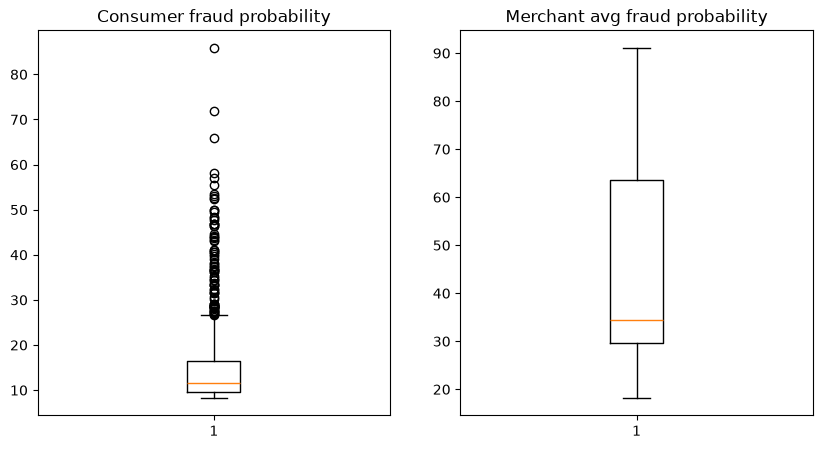

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].boxplot(pdf_consumer["fraud_probability"].dropna(), vert=True)
axes[0].set_title("Consumer fraud probability")
axes[1].boxplot(pdf_merchant["avg_merchant_fraud_prob"].dropna(), vert=True)
axes[1].set_title("Merchant avg fraud probability")
plt.show()

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


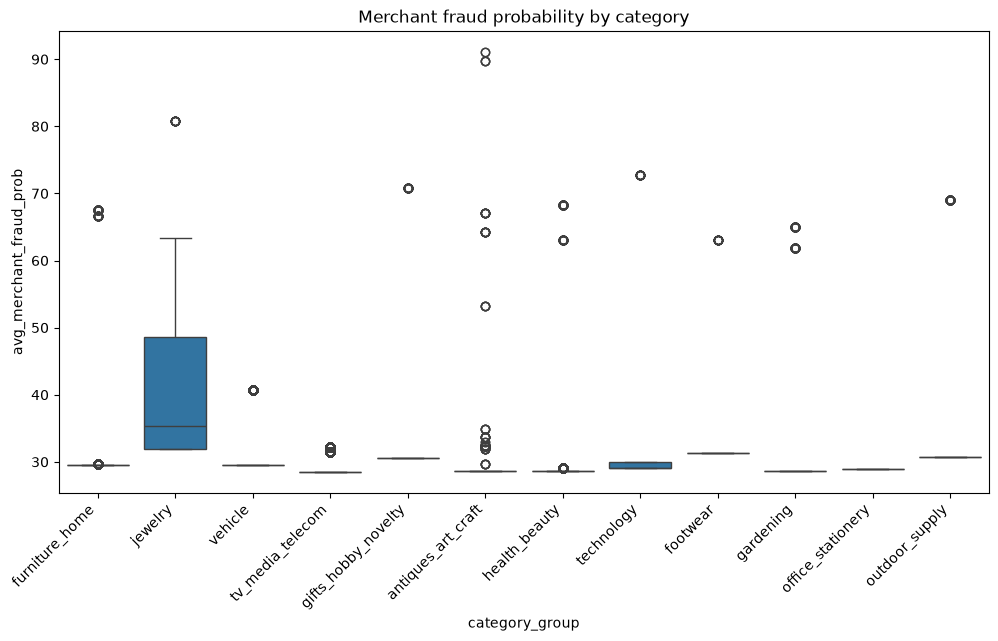

In [22]:
pdf_cat = (
    final_merged.select("category_group", "avg_merchant_fraud_prob")
    .dropna()
    .sample(0.05)
    .toPandas()
)

import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=pdf_cat, x="category_group", y="avg_merchant_fraud_prob")
plt.xticks(rotation=45, ha="right")
plt.title("Merchant fraud probability by category")
plt.show()

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


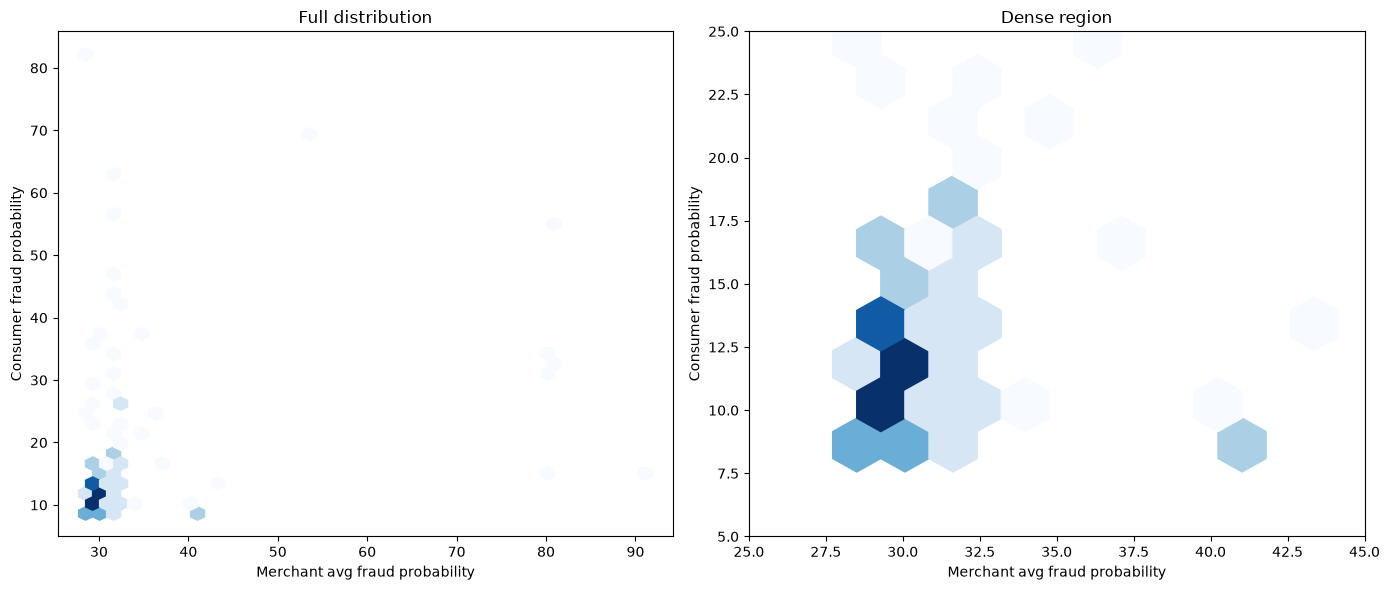

In [23]:
pdf_both = (
    final_merged.select("fraud_probability", "avg_merchant_fraud_prob")
    .dropna()
    .sample(0.01)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full range
axes[0].hexbin(
    pdf_both["avg_merchant_fraud_prob"],
    pdf_both["fraud_probability"],
    gridsize=40,
    cmap="Blues",
    mincnt=1
)
axes[0].set_title("Full distribution")
axes[0].set_xlabel("Merchant avg fraud probability")
axes[0].set_ylabel("Consumer fraud probability")

# Zoom into dense region
axes[1].hexbin(
    pdf_both["avg_merchant_fraud_prob"],
    pdf_both["fraud_probability"],
    gridsize=40,
    cmap="Blues",
    mincnt=1
)
axes[1].set_xlim(25, 45)
axes[1].set_ylim(5, 25)
axes[1].set_title("Dense region")
axes[1].set_xlabel("Merchant avg fraud probability")
axes[1].set_ylabel("Consumer fraud probability")

plt.tight_layout()
plt.show()

**Geospatial Analysis**

In [24]:
# formatting for geospatial plots

states_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "10m_cultural/ne_10m_admin_1_states_provinces.zip"
)

states = gpd.read_file(states_url)

states = states[
    states["admin"].str.contains("Australia", case=False, na=False)
].copy()

cities = {
    "Darwin": (130.8456, -12.4634),
    "Perth": (115.8605, -31.9505),
    "Adelaide": (138.6007, -34.9285),
    "Brisbane": (153.0251, -27.4698),
    "Sydney": (151.2093, -33.8688),
    "Canberra": (149.1300, -35.2809),
    "Melbourne": (144.9631, -37.8136),
    "Hobart": (147.3272, -42.8821),
}

city_gdf = gpd.GeoDataFrame(
    [
        {
            "city": city,
            "geometry": Point(lon, lat)
        }
        for city, (lon, lat) in cities.items()
    ],
    crs="EPSG:4326"
)

def plot_australia( # plot map function
    gdf,
    column,
    title,
    cmap="magma",
    figsize=(12, 8),
    legend=True,
    state_borders=True,
    show_cities=True,
    missing_color="lightgrey",
    border_color="white",
    border_width=1.0
):
    """
    Standardised Australia choropleth map.

    Parameters
    ----------
    gdf : GeoDataFrame
        Geographic data to plot.

    column : str
        Column used to colour the map.

    title : str
        Map title.

    cmap : str
        Matplotlib colourmap.

    figsize : tuple
        Figure dimensions.

    legend : bool
        Whether to show the colour legend.

    state_borders : bool
        Whether to show state/territory borders.

    show_cities : bool
        Whether to show major city locations.
    """

    gdf_plot = gdf.to_crs("EPSG:3577")

    states_plot = states.to_crs("EPSG:3577")
    cities_plot = city_gdf.to_crs("EPSG:3577")

    fig, ax = plt.subplots(
        figsize=figsize,
        facecolor="white"
    )

    gdf_plot.plot(
        column=column,
        cmap=cmap,
        legend=legend,
        ax=ax,
        linewidth=0,
        missing_kwds={
            "color": missing_color,
            "edgecolor": "white"
        },
        zorder=1
    )

    if state_borders:
        states_plot.boundary.plot(
            ax=ax,
            color=border_color,
            linewidth=border_width,
            alpha=0.9,
            zorder=3
        )

    if show_cities:

        cities_plot.plot(
            ax=ax,
            color="white",
            edgecolor="black",
            linewidth=0.8,
            markersize=35,
            zorder=5
        )

        offsets = {
            "Darwin": (6, 6),
            "Perth": (6, 6),
            "Adelaide": (6, -14),
            "Melbourne": (6, -14),
            "Hobart": (6, -14),
            "Canberra": (6, 6),
            "Sydney": (6, 6),
            "Brisbane": (6, 6),
        }

        for _, row in cities_plot.iterrows():

            ax.annotate(
                row["city"],
                xy=(
                    row.geometry.x,
                    row.geometry.y
                ),
                xytext=offsets.get(
                    row["city"],
                    (6, 6)
                ),
                textcoords="offset points",
                fontsize=9,
                color="white",
                weight="bold",
                zorder=6,
                path_effects=[
                    pe.withStroke(
                        linewidth=2.5,
                        foreground="black"
                    )
                ]
            )

    xmin, ymin, xmax, ymax = gdf_plot.total_bounds

    xpad = (xmax - xmin) * 0.02
    ypad = (ymax - ymin) * 0.02

    ax.set_xlim(
        xmin - xpad,
        xmax + xpad
    )

    ax.set_ylim(
        ymin - ypad,
        ymax + ypad
    )

    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=12
    )

    ax.set_axis_off()

    plt.tight_layout()

    return fig, ax

Spend per capita grouuped by postcode

In [25]:
import geopandas as gpd

# aggregate at postcode level in Spark
postcode_stats = (
    final_merged
    .groupBy("postcode")
    .agg(
        F.sum("dollar_value").alias("total_spend"),
        F.count("*").alias("n_txn"),
        F.avg("fraud_probability").alias("avg_fraud_prob"),
        F.avg("poa_population").alias("population"),
    )
    .toPandas()
)

postcode_stats["spend_per_capita"] = postcode_stats["total_spend"] / postcode_stats["population"]

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


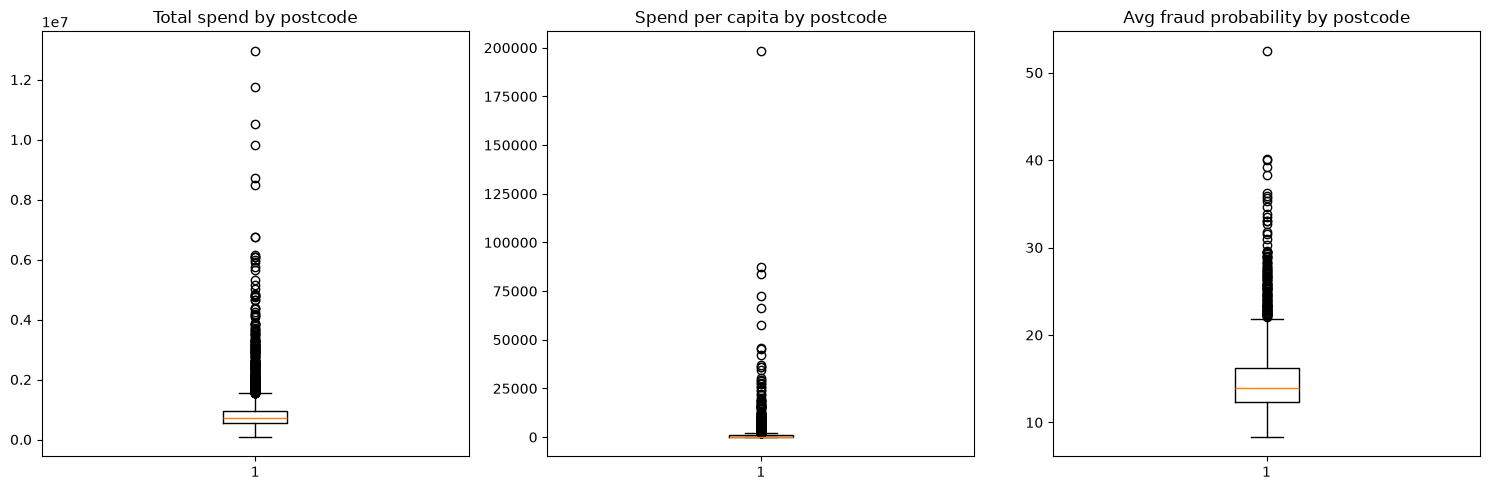

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(postcode_stats["total_spend"].dropna())
axes[0].set_title("Total spend by postcode")

axes[1].boxplot(postcode_stats["spend_per_capita"].dropna())
axes[1].set_title("Spend per capita by postcode")

axes[2].boxplot(postcode_stats["avg_fraud_prob"].dropna())
axes[2].set_title("Avg fraud probability by postcode")

plt.tight_layout()
plt.show()

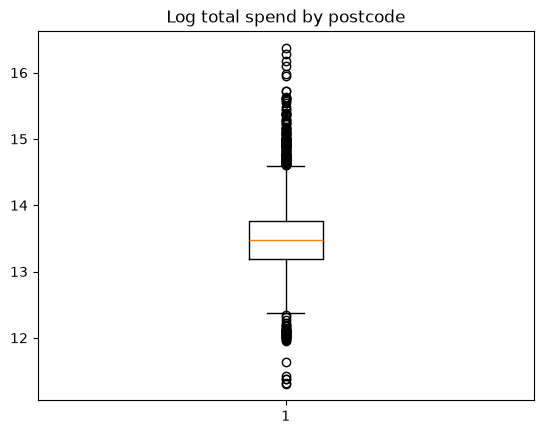

In [27]:
# transform data to fix skewness
postcode_stats["log_total_spend"] = np.log1p(postcode_stats["total_spend"])

plt.boxplot(postcode_stats["log_total_spend"].dropna())
plt.title("Log total spend by postcode")
plt.show()

In [28]:
# filter out small population
postcode_stats.sort_values("spend_per_capita", ascending=False).head(10)[["postcode", "population", "total_spend", "spend_per_capita"]]

# a) filter out unreliable small-population postcodes before computing per-capita
postcode_stats_filtered = postcode_stats[postcode_stats["population"] >= 100].copy()

# b) then log-transform what's left
postcode_stats_filtered["log_spend_per_capita"] = np.log1p(postcode_stats_filtered["spend_per_capita"])

In [29]:
poa = gpd.read_file("../data/landing/POA_2021_AUST_GDA2020.shp")[["POA_CODE21", "geometry"]]
poa = poa.rename(columns={"POA_CODE21": "postcode"})

poa_geo = poa.merge(postcode_stats, on="postcode", how="left")

In [30]:
# for spend-per-capita and orders-per-capita maps
poa_geo_filtered = poa.merge(postcode_stats_filtered, on="postcode", how="left")

# for total spend and fraud maps (no population filter needed)
poa_geo = poa.merge(postcode_stats, on="postcode", how="left")

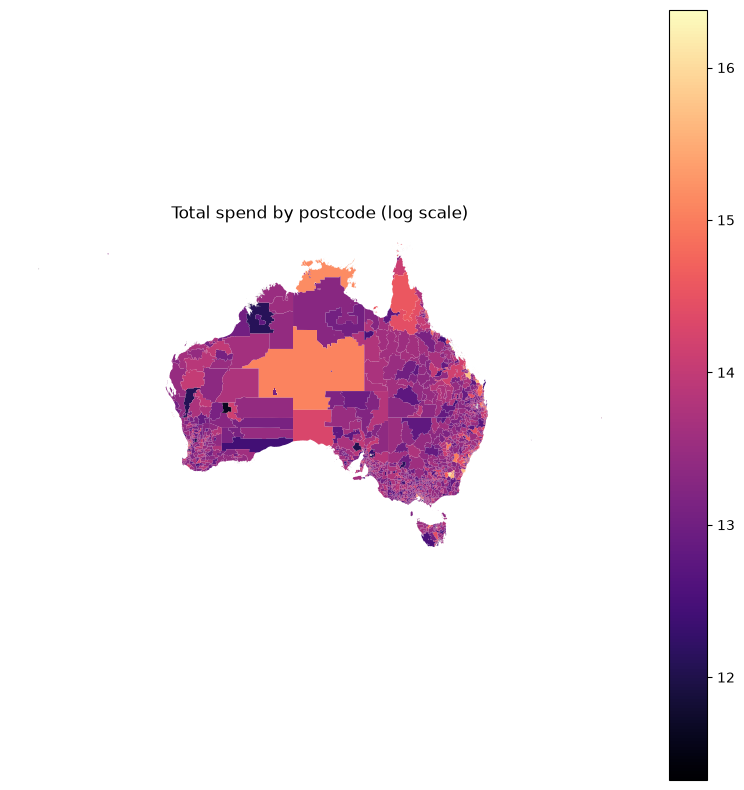

In [31]:
fig, ax = plt.subplots(figsize=(10, 10))
poa_geo.plot(column="log_total_spend", cmap="magma", legend=True, ax=ax,
             missing_kwds={"color": "lightgrey"})
ax.set_title("Total spend by postcode (log scale)")
ax.axis("off")
plt.show()

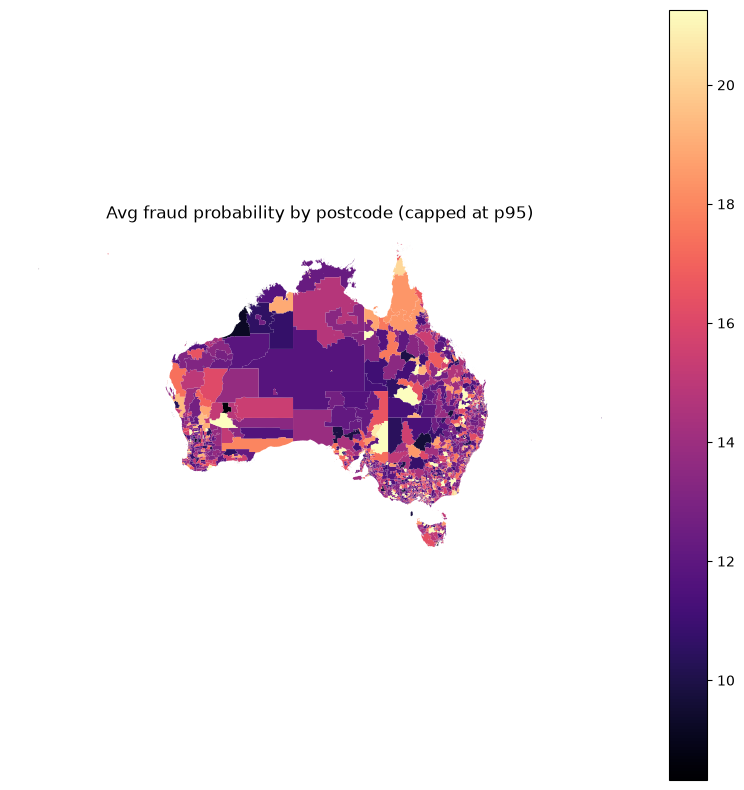

In [32]:
fig, ax = plt.subplots(figsize=(10, 10))
vmax = poa_geo["avg_fraud_prob"].quantile(0.95)
poa_geo.plot(column="avg_fraud_prob", cmap="magma", legend=True, vmax=vmax, ax=ax,
             missing_kwds={"color": "lightgrey"})
ax.set_title("Avg fraud probability by postcode (capped at p95)")
ax.axis("off")
plt.show()

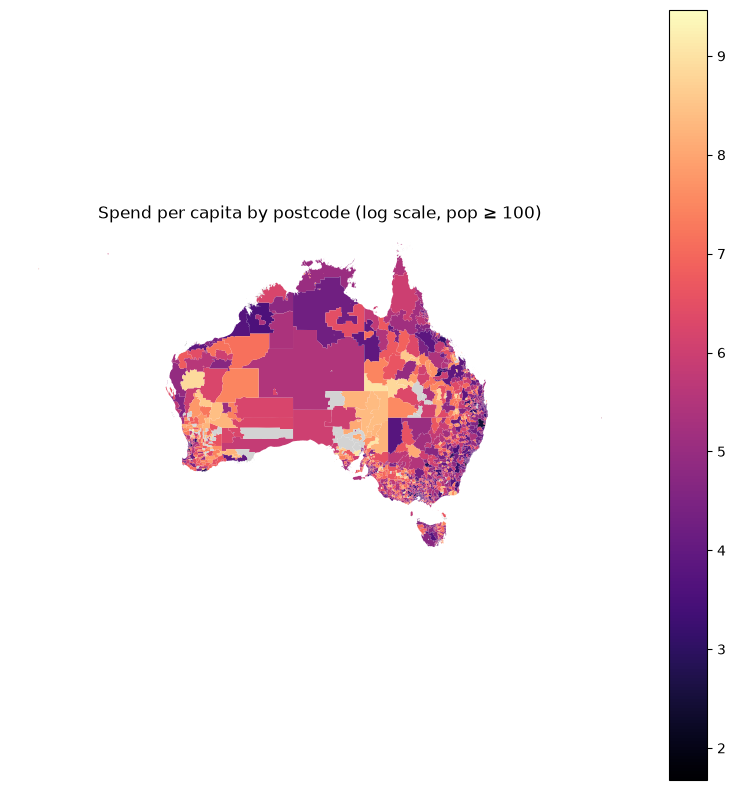

In [33]:
fig, ax = plt.subplots(figsize=(10, 10))
poa_geo_filtered.plot(column="log_spend_per_capita", cmap="magma", legend=True, ax=ax,
                       missing_kwds={"color": "lightgrey"})
ax.set_title("Spend per capita by postcode (log scale, pop ≥ 100)")
ax.axis("off")
plt.show()

Orders per capita grouuped by postcode

In [34]:
postcode_stats["orders_per_capita"] = postcode_stats["n_txn"] / postcode_stats["population"]
postcode_stats["log_n_txn"] = np.log1p(postcode_stats["n_txn"])

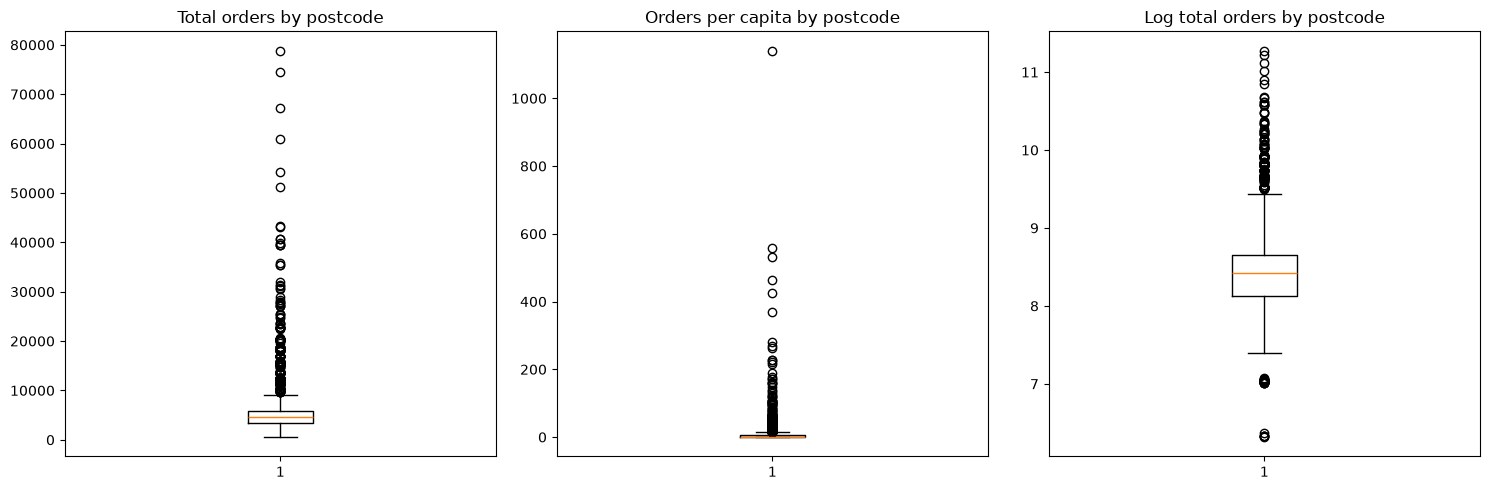

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(postcode_stats["n_txn"].dropna())
axes[0].set_title("Total orders by postcode")

axes[1].boxplot(postcode_stats["orders_per_capita"].dropna())
axes[1].set_title("Orders per capita by postcode")

axes[2].boxplot(postcode_stats["log_n_txn"].dropna())
axes[2].set_title("Log total orders by postcode")

plt.tight_layout()
plt.show()

In [36]:
postcode_stats.sort_values("orders_per_capita", ascending=False).head(10)[
    ["postcode", "population", "n_txn", "orders_per_capita"]
]

,postcode,population,n_txn,orders_per_capita
2626,6452,4.0,4563,1140.750000
2203,4479,7.0,3897,556.714286
2797,6470,20.0,10660,533.000000
1790,4009,11.0,5099,463.545455
2152,6385,20.0,8501,425.050000
2520,5713,20.0,7374,368.700000
2448,3415,36.0,10139,281.638889
651,4493,19.0,5094,268.105263
1580,6467,30.0,7927,264.233333
1650,3893,25.0,5717,228.680000


In [37]:
# reuse the population filter already applied for spend-per-capita
postcode_stats_filtered["orders_per_capita"] = (
    postcode_stats_filtered["n_txn"] / postcode_stats_filtered["population"]
)
postcode_stats_filtered["log_orders_per_capita"] = np.log1p(
    postcode_stats_filtered["orders_per_capita"]
)

In [38]:
poa_geo = poa.merge(postcode_stats, on="postcode", how="left")
poa_geo_filtered = poa.merge(postcode_stats_filtered, on="postcode", how="left")

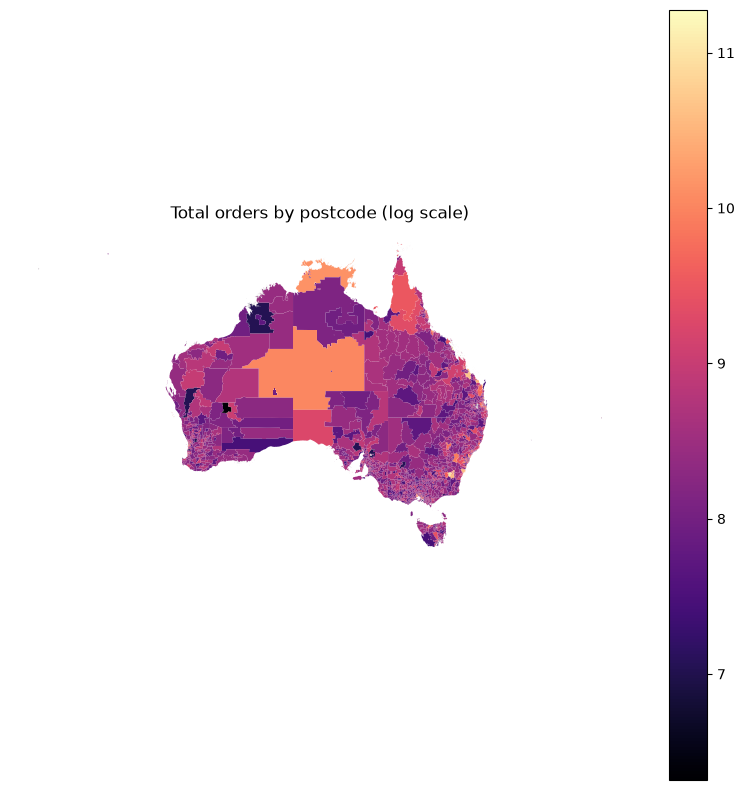

Text(740.5277777777778, 0.5, 'log(total orders + 1)')

In [39]:
fig, ax = plt.subplots(figsize=(10, 10))
poa_geo.plot(column="log_n_txn", cmap="magma", legend=True, ax=ax,
             missing_kwds={"color": "lightgrey"})
ax.set_title("Total orders by postcode (log scale)")
ax.axis("off")
plt.show()

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("log(total orders + 1)")

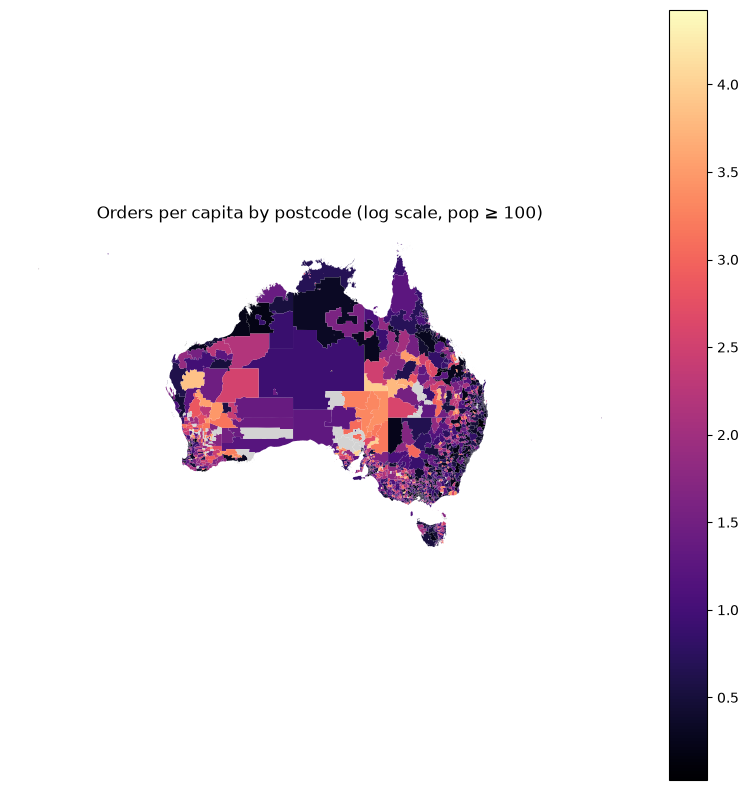

Text(744.5277777777778, 0.5, 'log(orders per capita + 1)')

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))
poa_geo_filtered.plot(column="log_orders_per_capita", cmap="magma", legend=True, ax=ax,
                       missing_kwds={"color": "lightgrey"})
ax.set_title("Orders per capita by postcode (log scale, pop ≥ 100)")
ax.axis("off")
plt.show()

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("log(orders per capita + 1)")